In [1]:
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
import seaborn as sns
from config import Config

from mfcc import mfcc

In [2]:
rate, signal = wav.read(Config.BASEDIR + "/one/210f3aa9_nohash_1.wav")

signal = signal[:rate * 3]

features = mfcc(signal, rate)
print(features.shape)

(84, 13)


In [3]:
mfcc_custom = mfcc(signal, rate, n_ceps=26, n_filt=52, n_fft=2048)

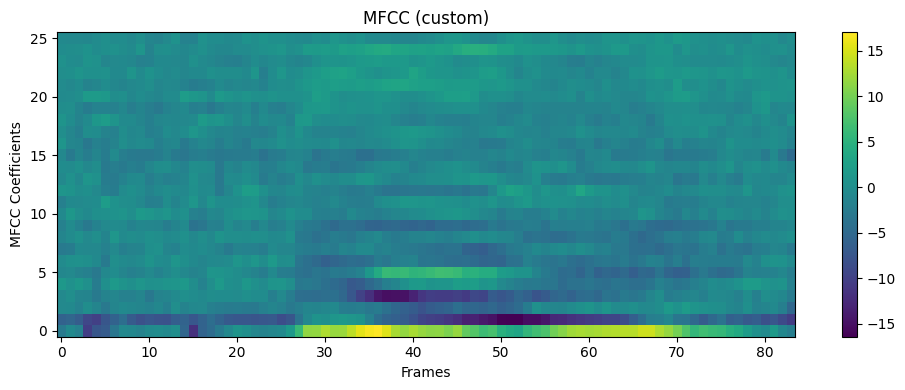

In [4]:
plt.figure(figsize=(10, 4))
plt.imshow(mfcc_custom.T, interpolation="nearest", origin="lower", aspect="auto")
plt.title("MFCC (custom)")
plt.xlabel("Frames")
plt.ylabel("MFCC Coefficients")
plt.colorbar()
plt.tight_layout()
plt.show()

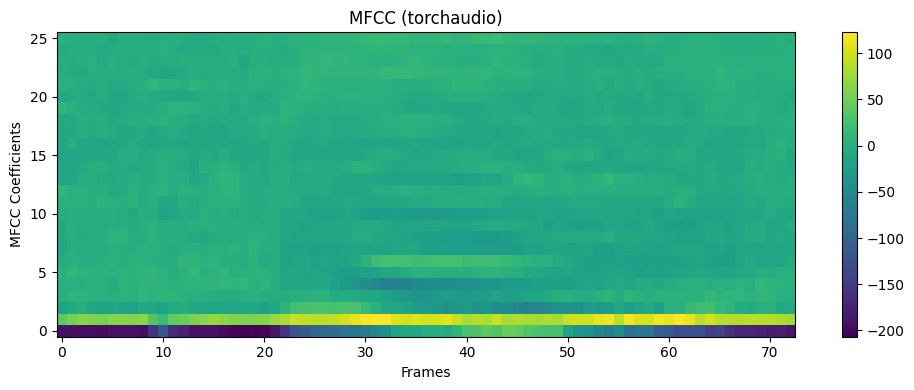

In [29]:
import torch
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt

num_mfcc = 26
num_mels = 52
duration_sec = 1

audio, fs = torchaudio.load(Config.BASEDIR + "/one/210f3aa9_nohash_1.wav")  # audio.shape = (channels, samples)
num_samples = int(duration_sec * fs)
audio = audio[:, :num_samples]

win_length = int(0.025 * fs)  # 25 ms
hop_length = int(0.010 * fs)  # 10 ms
n_fft = 2048

mfcc_transform = T.MFCC(
    sample_rate=fs,
    n_mfcc=num_mfcc,
    melkwargs={
        'n_fft': n_fft,
        'win_length': win_length,
        'hop_length': hop_length,
        'n_mels': num_mels,
        'window_fn': torch.hamming_window,
        'center': False
    }
)

mfcc_torch = mfcc_transform(audio)

plt.figure(figsize=(10, 4))
plt.imshow(mfcc_torch[0].numpy(), interpolation="nearest", origin="lower", aspect="auto")
plt.title("MFCC (torchaudio)")
plt.xlabel("Frames")
plt.ylabel("MFCC Coefficients")
plt.colorbar()
plt.tight_layout()
plt.show()